In [2]:
# ============================================================
# BLOCK 1: Imports, reproducibility, and environment check
# ============================================================

# --- Standard library ---
import os
import time
import random
import zipfile
import urllib.request
from pathlib import Path

# --- Numerical / data handling ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: preprocessing, splitting, metrics ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout,
    Embedding, RepeatVector, TimeDistributed,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Video part (Section 18-21): pretrained CNN + frame handling ---
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import cv2   # reads videos and extracts frames

# --- Reproducibility ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Plot styling ---
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

# --- Environment check ---
print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("NumPy version      :", np.__version__)
print("GPU available      :", tf.config.list_physical_devices("GPU"))

TensorFlow version : 2.20.0
Keras version      : 3.13.2
NumPy version      : 2.0.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# BLOCK 2: Download and load UCI HAR raw inertial signals
# ============================================================

DATA_ROOT = Path.cwd() / "har_data"
DATA_ROOT.mkdir(exist_ok=True)

HAR_URL = ("https://archive.ics.uci.edu/static/public/240/"
           "human+activity+recognition+using+smartphones.zip")

# The 9 channels, in a fixed order (this order defines the "F" axis)
SIGNAL_NAMES = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",     # body acceleration (gravity removed)
    "body_gyro_x", "body_gyro_y", "body_gyro_z",    # gyroscope (angular velocity)
    "total_acc_x", "total_acc_y", "total_acc_z",    # total acceleration (includes gravity)
]

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                  "SITTING", "STANDING", "LAYING"]


def find_har_root():
    """Find the real 'UCI HAR Dataset' folder, ignoring macOS junk folders."""
    for base in [DATA_ROOT, Path("/kaggle/input")]:
        if base.exists():
            for p in base.rglob("Inertial Signals"):
                if "__MACOSX" in p.parts:
                    continue                                   # skip the fake copy
                if (p / "body_acc_x_train.txt").exists() or \
                   (p.parent / "train").exists() and any(p.glob("body_acc_x_*.txt")):
                    return p.parent.parent                     # .../UCI HAR Dataset
    return None


def download_har():
    zip_path = DATA_ROOT / "har.zip"
    print("Downloading UCI HAR dataset...")
    req = urllib.request.Request(HAR_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as r, open(zip_path, "wb") as f:
        f.write(r.read())
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_ROOT)
    # The UCI archive sometimes contains a second, nested zip
    for inner in DATA_ROOT.rglob("*.zip"):
        if inner != zip_path:
            with zipfile.ZipFile(inner) as z:
                z.extractall(DATA_ROOT)


HAR_ROOT = find_har_root()
if HAR_ROOT is None:
    download_har()
    HAR_ROOT = find_har_root()

assert HAR_ROOT is not None, (
    "Dataset not found. On Kaggle: enable Internet or attach the HAR dataset. "
    "Otherwise download it manually from the UCI link in the lab sheet."
)
print("Dataset folder:", HAR_ROOT)


def load_split(split):
    """Load one split ('train' or 'test') -> X: (N, 128, 9), y: (N,) with labels 0-5."""
    channels = []
    for name in SIGNAL_NAMES:
        path = HAR_ROOT / split / "Inertial Signals" / f"{name}_{split}.txt"
        channels.append(pd.read_csv(path, sep=r"\s+", header=None).values)  # (N, 128)
    X = np.stack(channels, axis=-1).astype(np.float32)                      # (N, 128, 9)
    y = pd.read_csv(HAR_ROOT / split / f"y_{split}.txt", header=None).values.ravel() - 1
    return X, y.astype(np.int64)


X_train_raw, y_train_raw = load_split("train")
X_test_raw,  y_test_raw  = load_split("test")

# ---------- Sanity checks ----------
print("\nX_train_raw:", X_train_raw.shape, "| y_train_raw:", y_train_raw.shape)
print("X_test_raw :", X_test_raw.shape,  "| y_test_raw :", y_test_raw.shape)

print("\nClass distribution (train):")
for i, name in enumerate(ACTIVITY_NAMES):
    print(f"  {i} {name:<20} {np.sum(y_train_raw == i)}")

print("\nOne sample window, first 3 time steps (9 channels each):")
print(pd.DataFrame(X_train_raw[0, :3], columns=SIGNAL_NAMES).round(4).to_string())
print("Its label:", ACTIVITY_NAMES[y_train_raw[0]])

Dataset folder: /kaggle/working/har_data/UCI HAR Dataset

X_train_raw: (7352, 128, 9) | y_train_raw: (7352,)
X_test_raw : (2947, 128, 9) | y_test_raw : (2947,)

Class distribution (train):
  0 WALKING              1226
  1 WALKING_UPSTAIRS     1073
  2 WALKING_DOWNSTAIRS   986
  3 SITTING              1286
  4 STANDING             1374
  5 LAYING               1407

One sample window, first 3 time steps (9 channels each):
   body_acc_x  body_acc_y  body_acc_z  body_gyro_x  body_gyro_y  body_gyro_z  total_acc_x  total_acc_y  total_acc_z
0      0.0002      0.0108      0.0556       0.0302       0.0660       0.0229       1.0128      -0.1232       0.1029
1      0.0101      0.0066      0.0551       0.0437       0.0427       0.0103       1.0228      -0.1269       0.1057
2      0.0093      0.0089      0.0484       0.0357       0.0749       0.0132       1.0220      -0.1240       0.1021
Its label: STANDING


In [4]:
# ============================================================
# BLOCK 3: Balanced subset, 70/15/15 split, normalization
# ============================================================

# ---------- 1. Balanced subset (lab recommends 1500-3000 windows) ----------
N_PER_CLASS = 400                      # 6 classes x 400 = 2400 windows
rng = np.random.default_rng(SEED)

subset_idx = []
for c in range(6):
    idx_c = np.where(y_train_raw == c)[0]
    subset_idx.append(rng.choice(idx_c, size=N_PER_CLASS, replace=False))
subset_idx = np.concatenate(subset_idx)
rng.shuffle(subset_idx)                # mix the classes together

X_sub = X_train_raw[subset_idx]        # (2400, 128, 9)
y_sub = y_train_raw[subset_idx]        # (2400,)
print("Subset:", X_sub.shape, y_sub.shape)

# ---------- 2. Labels ----------
# Labels are already encoded as integers 0-5 (see ACTIVITY_NAMES for the mapping).
# That is exactly what sparse categorical cross-entropy expects, so no one-hot is needed.

# ---------- 3. Stratified 70 / 15 / 15 split ----------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# ---------- 4. Normalization (statistics from TRAINING data only) ----------
# One mean and one std per channel, computed over all training windows and time steps
mean = X_train.mean(axis=(0, 1), keepdims=True)     # shape (1, 1, 9)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = ((X_train - mean) / std).astype(np.float32)
X_val   = ((X_val   - mean) / std).astype(np.float32)
X_test  = ((X_test  - mean) / std).astype(np.float32)

# ---------- 5. Required printout ----------
NUM_CLASSES = 6
SEQ_LEN     = X_train.shape[1]
NUM_FEATS   = X_train.shape[2]

print("\nInput tensor shape:")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)
print("\nNumber of classes:", NUM_CLASSES)
print("Number of features per time step:", NUM_FEATS)
print("Sequence length:", SEQ_LEN)

# ---------- 6. Verify class distribution ----------
dist = pd.DataFrame({
    "Train": np.bincount(y_train, minlength=6),
    "Val":   np.bincount(y_val,   minlength=6),
    "Test":  np.bincount(y_test,  minlength=6),
}, index=ACTIVITY_NAMES)
print("\nClass distribution per split:")
print(dist)

# ---------- 7. Normalization check ----------
print("\nTrain per-channel mean (should be ~0):", X_train.mean(axis=(0, 1)).round(3))
print("Train per-channel std  (should be ~1):", X_train.std(axis=(0, 1)).round(3))

Subset: (2400, 128, 9) (2400,)

Input tensor shape:
Training   : (1680, 128, 9)
Validation : (360, 128, 9)
Testing    : (360, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution per split:
                    Train  Val  Test
WALKING               280   60    60
WALKING_UPSTAIRS      280   60    60
WALKING_DOWNSTAIRS    280   60    60
SITTING               280   60    60
STANDING              280   60    60
LAYING                280   60    60

Train per-channel mean (should be ~0): [-0. -0.  0.  0.  0.  0.  0. -0. -0.]
Train per-channel std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


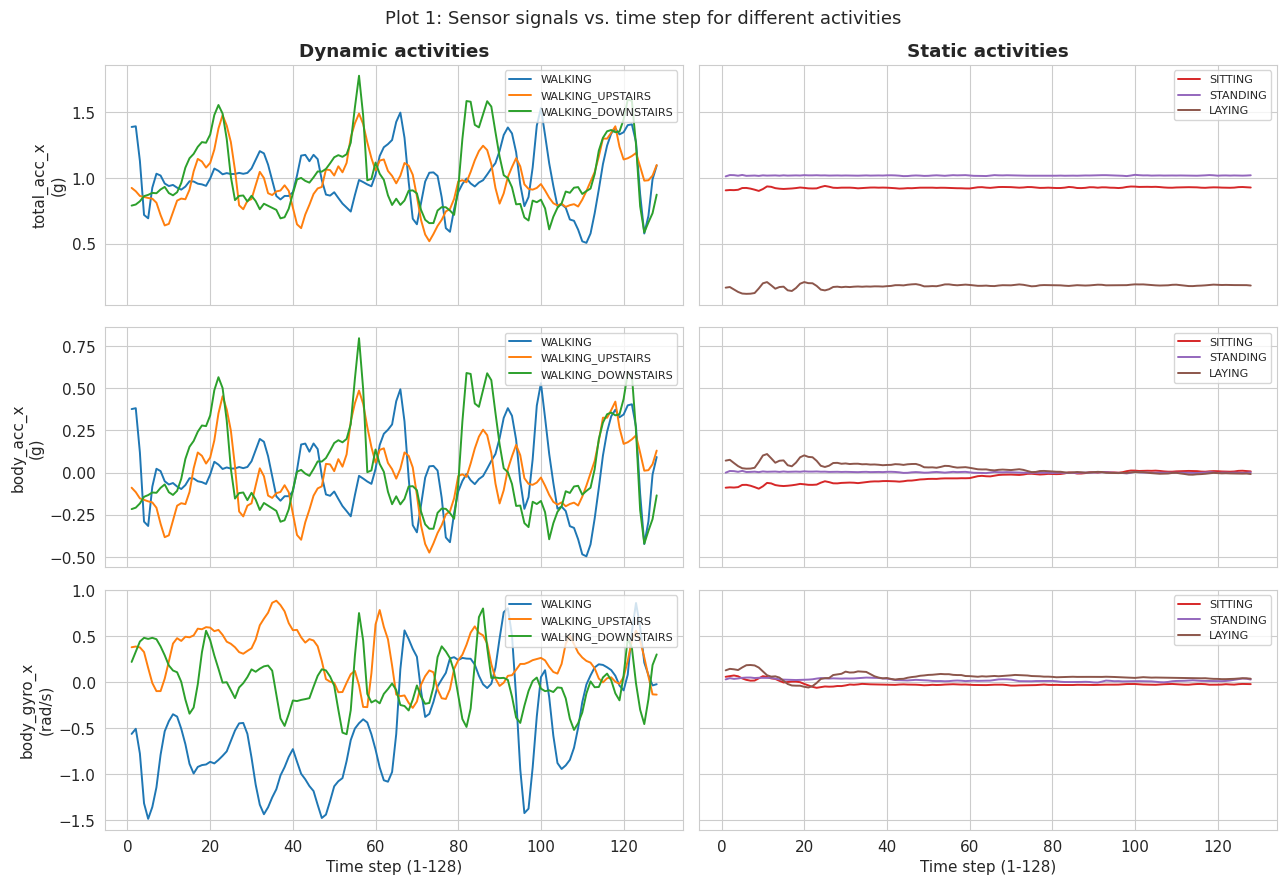

Activity                   WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
total_acc_x mean             0.995             0.949               0.992    0.951     1.001   0.072
total_acc_x std_in_window    0.224             0.253               0.370    0.005     0.005   0.010
body_acc_x mean             -0.000            -0.003               0.002   -0.001     0.000  -0.002
body_acc_x std_in_window     0.224             0.253               0.370    0.007     0.006   0.015
body_gyro_x mean            -0.004             0.050              -0.051   -0.010     0.001   0.011
body_gyro_x std_in_window    0.469             0.469               0.594    0.018     0.044   0.032


In [5]:
# ============================================================
# BLOCK 4: Plot 1 - Sensor signal vs. time step
# ============================================================

CHANNELS_TO_PLOT = ["total_acc_x", "body_acc_x", "body_gyro_x"]   # you can change these
UNITS = {"acc": "g", "gyro": "rad/s"}

T = X_train_raw.shape[1]                    # 128
t = np.arange(1, T + 1)                     # time steps 1..128

# One representative window per activity (first window of each class)
sample_idx = {c: np.where(y_train_raw == c)[0][0] for c in range(6)}

groups = {
    "Dynamic activities": [0, 1, 2],        # walking, upstairs, downstairs
    "Static activities":  [3, 4, 5],        # sitting, standing, laying
}
colors = plt.cm.tab10(np.arange(6))

fig, axes = plt.subplots(len(CHANNELS_TO_PLOT), 2, figsize=(13, 9),
                         sharex=True, sharey="row")

for r, ch in enumerate(CHANNELS_TO_PLOT):
    ch_i = SIGNAL_NAMES.index(ch)
    unit = UNITS["gyro"] if "gyro" in ch else UNITS["acc"]
    for col, (title, classes) in enumerate(groups.items()):
        ax = axes[r, col]
        for c in classes:
            ax.plot(t, X_train_raw[sample_idx[c], :, ch_i],
                    label=ACTIVITY_NAMES[c], color=colors[c], lw=1.4)
        if r == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{ch}\n({unit})")
        if r == len(CHANNELS_TO_PLOT) - 1:
            ax.set_xlabel("Time step (1-128)")
        ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Plot 1: Sensor signals vs. time step for different activities", fontsize=13)
plt.tight_layout()
plt.show()

# ---------- Numerical support for your inference ----------
# 'std_in_window' = how much the signal fluctuates inside one 2.56 s window (averaged over all
# training windows of that activity). Big value = lots of motion, small value = nearly still.
rows = []
for c in range(6):
    w = X_train_raw[y_train_raw == c]                 # (n_c, 128, 9)
    row = {"Activity": ACTIVITY_NAMES[c]}
    for ch in CHANNELS_TO_PLOT:
        i = SIGNAL_NAMES.index(ch)
        row[f"{ch} mean"] = w[:, :, i].mean()
        row[f"{ch} std_in_window"] = w[:, :, i].std(axis=1).mean()
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Activity").round(3)
print(summary.T.to_string())

In [6]:
# ============================================================
# BLOCK 5: Numerical exercise - manual RNN forward pass + check
# ============================================================
import math

x  = [0.5, 0.7, 0.2]     # x1, x2, x3
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

# ---------- Method 1: step by step in plain Python (mirrors the hand calculation) ----------
print("Method 1: manual calculation")
h_prev, h_manual, a_list = h0, [], []
for t, xt in enumerate(x, start=1):
    a = Wx * xt + Wh * h_prev + b          # pre-activation
    h = math.tanh(a)                        # h_t = tanh(Wx*x_t + Wh*h_{t-1} + b)
    print(f"  t={t}: a = {Wx}*{xt} + {Wh}*{h_prev:.4f} + {b} = {a:.4f}  ->  h{t} = tanh({a:.4f}) = {h:.4f}")
    a_list.append(a); h_manual.append(h); h_prev = h

# ---------- Method 2: NumPy ----------
h_np, h_prev = [], np.float64(h0)
for xt in x:
    h_prev = np.tanh(Wx * xt + Wh * h_prev + b)
    h_np.append(h_prev)

# ---------- Method 3: real Keras SimpleRNN with the same weights ----------
inp = Input(shape=(3, 1))                                    # (time steps=3, features=1)
rnn = SimpleRNN(1, activation="tanh", return_sequences=True, name="rnn_check")
model_check = Model(inp, rnn(inp))
rnn.set_weights([np.array([[Wx]]),      # input kernel  Wx, shape (1, 1)
                 np.array([[Wh]]),      # recurrent kernel Wh, shape (1, 1)
                 np.array([b])])        # bias b, shape (1,)
h_keras = model_check.predict(np.array(x, dtype="float32").reshape(1, 3, 1), verbose=0).ravel()

print("\nComparison")
print(pd.DataFrame({"Manual": h_manual, "NumPy": h_np, "Keras": h_keras},
                   index=["h1", "h2", "h3"]).round(6))
print("All three agree:", np.allclose(h_manual, h_np) and np.allclose(h_manual, h_keras, atol=1e-6))

# ---------- Bonus: why gradients vanish (link to BPTT) ----------
# For h_t = tanh(a_t):  dh_t/dh_{t-1} = (1 - h_t^2) * Wh
d32 = (1 - h_manual[2]**2) * Wh
d21 = (1 - h_manual[1]**2) * Wh
print(f"\ndh3/dh2 = (1 - h3^2)*Wh = {d32:.4f}")
print(f"dh2/dh1 = (1 - h2^2)*Wh = {d21:.4f}")
print(f"dh3/dh1 = product       = {d32 * d21:.4f}")

Method 1: manual calculation
  t=1: a = 0.5*0.5 + 0.8*0.0000 + 0.1 = 0.3500  ->  h1 = tanh(0.3500) = 0.3364
  t=2: a = 0.5*0.7 + 0.8*0.3364 + 0.1 = 0.7191  ->  h2 = tanh(0.7191) = 0.6164
  t=3: a = 0.5*0.2 + 0.8*0.6164 + 0.1 = 0.6931  ->  h3 = tanh(0.6931) = 0.6000


I0000 00:00:1789810825.501595      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789810825.504450      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Comparison
      Manual     NumPy     Keras
h1  0.336376  0.336376  0.336376
h2  0.616352  0.616352  0.616352
h3  0.599958  0.599958  0.599958
All three agree: True

dh3/dh2 = (1 - h3^2)*Wh = 0.5120
dh2/dh1 = (1 - h2^2)*Wh = 0.4961
dh3/dh1 = product       = 0.2540


I0000 00:00:1789810827.355234     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [9]:
print(5)

5


Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 - 6s - 117ms/step - accuracy: 0.3488 - loss: 1.6553 - val_accuracy: 0.4833 - val_loss: 1.5129
Epoch 2/30
53/53 - 1s - 12ms/step - accuracy: 0.4143 - loss: 1.4711 - val_accuracy: 0.4056 - val_loss: 1.3441
Epoch 3/30
53/53 - 1s - 12ms/step - accuracy: 0.4250 - loss: 1.2920 - val_accuracy: 0.4306 - val_loss: 1.2028
Epoch 4/30
53/53 - 1s - 12ms/step - accuracy: 0.4685 - loss: 1.1798 - val_accuracy: 0.5333 - val_loss: 1.1218
Epoch 5/30
53/53 - 1s - 12ms/step - accuracy: 0.5411 - loss: 1.0967 - val_accuracy: 0.5694 - val_loss: 1.0131
Epoch 6/30
53/53 - 1s - 12ms/step - accuracy: 0.5893 - loss: 0.9880 - val_accuracy: 0.6278 - val_loss: 0.9069
Epoch 7/30
53/53 - 1s - 12ms/step - accuracy: 0.6268 - loss: 0.8785 - val_accuracy: 0.6667 - val_loss: 0.7958
Epoch 8/30
53/53 - 1s - 12ms/step - accuracy: 0.6464 - loss: 0.8060 - val_accuracy: 0.6694 - val_loss: 0.7504
Epoch 9/30
53/53 - 1s - 12ms/step - accuracy: 0.5262 - loss: 1.1493 - val_accuracy: 0.4222 - val_loss: 1.1781
Epoch 10/

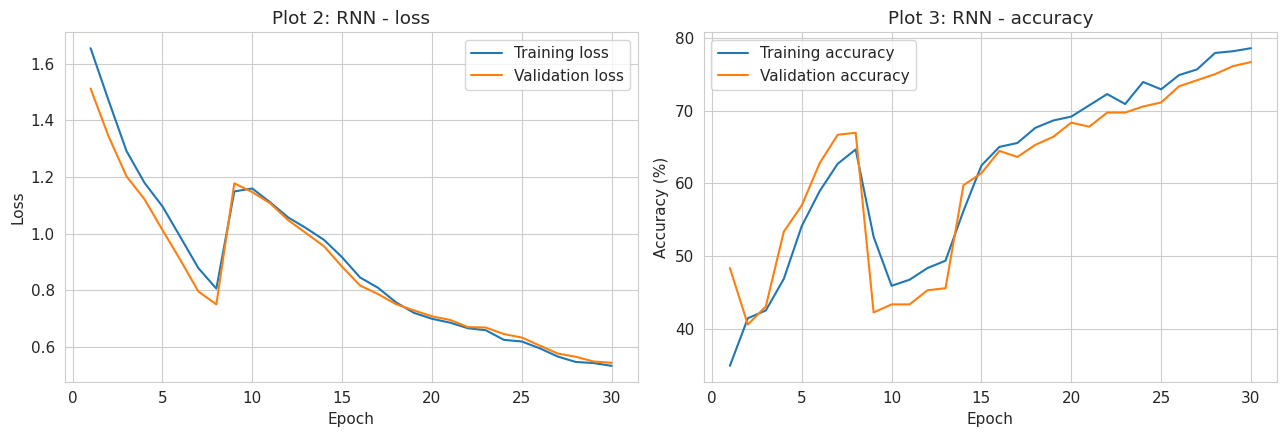

In [7]:
# ============================================================
# BLOCK 6: Model builder, training helper, and Vanilla RNN
# ============================================================

# ---------- Shared configuration (identical for RNN, LSTM, GRU) ----------
UNITS, DROPOUT, DENSE_UNITS = 32, 0.2, 16
LR, BATCH_SIZE, EPOCHS = 1e-3, 32, 30

RNN_LAYERS = {"RNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}


def build_model(kind, seq_len=SEQ_LEN, n_feats=NUM_FEATS):
    """Input -> recurrent layer (32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(6, softmax)."""
    keras.utils.set_random_seed(SEED)                    # same seed for every model
    inp = Input(shape=(seq_len, n_feats), name="input")
    x = RNN_LAYERS[kind](UNITS, name=kind.lower())(inp)  # returns only the LAST hidden state
    x = Dropout(DROPOUT)(x)
    x = Dense(DENSE_UNITS, activation="relu")(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inp, out, name=kind)
    model.compile(optimizer=Adam(learning_rate=LR),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


results, histories, models = {}, {}, {}


def train_model(kind, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val, tag=None):
    """Train one model with the shared configuration and record time and parameters."""
    tag = tag or kind
    model = build_model(kind, seq_len=X_tr.shape[1])
    start = time.time()
    hist = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                     epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
    elapsed = time.time() - start
    models[tag], histories[tag] = model, hist.history
    results[tag] = {"params": model.count_params(), "train_time_s": elapsed}
    print(f"\n[{tag}] trainable parameters: {model.count_params():,} | training time: {elapsed:.1f} s")
    return model


def plot_history(tag):
    """Plot 2 (loss) and Plot 3 (accuracy in %) for one model."""
    h = histories[tag]
    ep = np.arange(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(ep, h["loss"], label="Training loss")
    ax[0].plot(ep, h["val_loss"], label="Validation loss")
    ax[0].set(title=f"Plot 2: {tag} - loss", xlabel="Epoch", ylabel="Loss")
    ax[1].plot(ep, np.array(h["accuracy"]) * 100, label="Training accuracy")
    ax[1].plot(ep, np.array(h["val_accuracy"]) * 100, label="Validation accuracy")
    ax[1].set(title=f"Plot 3: {tag} - accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for a in ax:
        a.legend()
    plt.tight_layout()
    plt.show()


# ---------- GPU warm-up so the first model's timing isn't inflated ----------
# The first fit on a fresh runtime pays one-time initialisation costs. Doing a throwaway
# run first keeps the timing comparison across RNN/LSTM/GRU fair.
_ = build_model("LSTM").fit(X_train[:64], y_train[:64], epochs=1, batch_size=32, verbose=0)
_ = build_model("RNN").fit(X_train[:64], y_train[:64], epochs=1, batch_size=32, verbose=0)

# ---------- Train the Vanilla RNN ----------
build_model("RNN").summary()
train_model("RNN")

print(f"\nFinal RNN  train acc: {histories['RNN']['accuracy'][-1]*100:.2f}% | "
      f"val acc: {histories['RNN']['val_accuracy'][-1]*100:.2f}%")
plot_history("RNN")

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 - 2s - 44ms/step - accuracy: 0.3524 - loss: 1.6448 - val_accuracy: 0.3917 - val_loss: 1.4709
Epoch 2/30
53/53 - 1s - 11ms/step - accuracy: 0.4887 - loss: 1.2806 - val_accuracy: 0.6500 - val_loss: 1.0381
Epoch 3/30
53/53 - 1s - 11ms/step - accuracy: 0.6280 - loss: 1.0113 - val_accuracy: 0.6972 - val_loss: 0.9237
Epoch 4/30
53/53 - 1s - 11ms/step - accuracy: 0.6857 - loss: 0.8765 - val_accuracy: 0.7139 - val_loss: 0.7787
Epoch 5/30
53/53 - 1s - 11ms/step - accuracy: 0.7065 - loss: 0.7425 - val_accuracy: 0.7750 - val_loss: 0.6405
Epoch 6/30
53/53 - 1s - 11ms/step - accuracy: 0.7518 - loss: 0.6306 - val_accuracy: 0.8056 - val_loss: 0.5242
Epoch 7/30
53/53 - 1s - 11ms/step - accuracy: 0.8131 - loss: 0.4985 - val_accuracy: 0.8194 - val_loss: 0.4318
Epoch 8/30
53/53 - 1s - 11ms/step - accuracy: 0.8381 - loss: 0.4390 - val_accuracy: 0.8694 - val_loss: 0.3543
Epoch 9/30
53/53 - 1s - 12ms/step - accuracy: 0.8631 - loss: 0.3554 - val_accuracy: 0.9167 - val_loss: 0.3023
Epoch 10/3

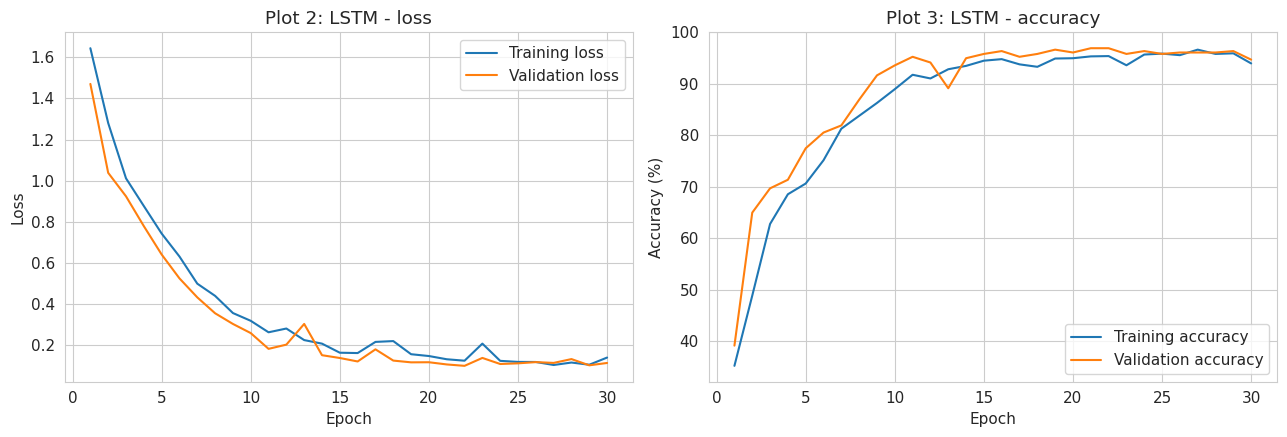

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 - 2s - 41ms/step - accuracy: 0.3208 - loss: 1.6507 - val_accuracy: 0.4361 - val_loss: 1.4806
Epoch 2/30
53/53 - 1s - 19ms/step - accuracy: 0.4226 - loss: 1.4233 - val_accuracy: 0.5056 - val_loss: 1.3328
Epoch 3/30
53/53 - 1s - 11ms/step - accuracy: 0.5530 - loss: 1.2446 - val_accuracy: 0.5861 - val_loss: 1.0865
Epoch 4/30
53/53 - 1s - 11ms/step - accuracy: 0.6119 - loss: 1.0049 - val_accuracy: 0.6889 - val_loss: 0.8538
Epoch 5/30
53/53 - 1s - 11ms/step - accuracy: 0.7101 - loss: 0.7820 - val_accuracy: 0.7778 - val_loss: 0.6279
Epoch 6/30
53/53 - 1s - 11ms/step - accuracy: 0.7696 - loss: 0.5873 - val_accuracy: 0.8028 - val_loss: 0.4788
Epoch 7/30
53/53 - 1s - 11ms/step - accuracy: 0.8167 - loss: 0.4454 - val_accuracy: 0.8278 - val_loss: 0.3781
Epoch 8/30
53/53 - 1s - 12ms/step - accuracy: 0.8220 - loss: 0.4153 - val_accuracy: 0.8639 - val_loss: 0.3479
Epoch 9/30
53/53 - 1s - 11ms/step - accuracy: 0.8542 - loss: 0.3712 - val_accuracy: 0.9000 - val_loss: 0.3082
Epoch 10/3

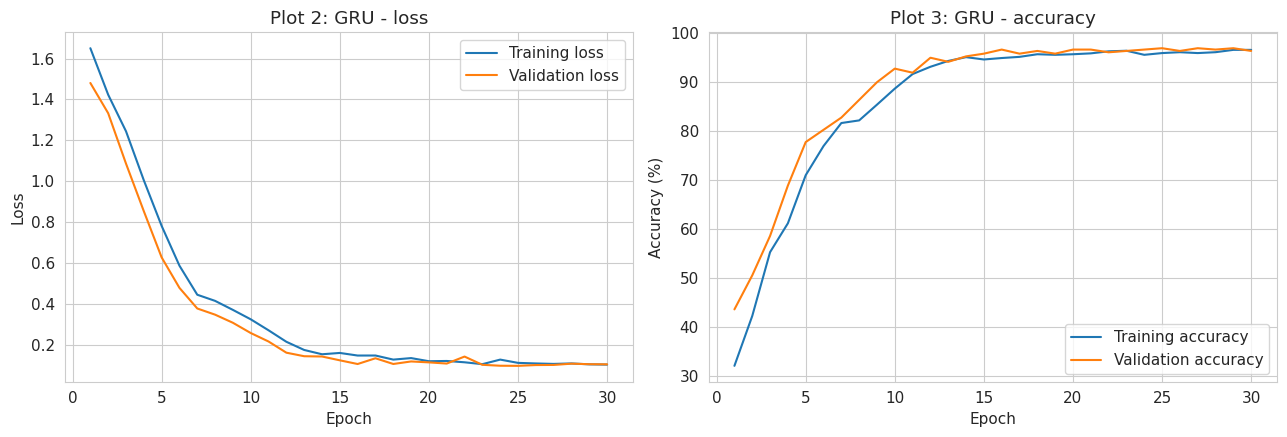

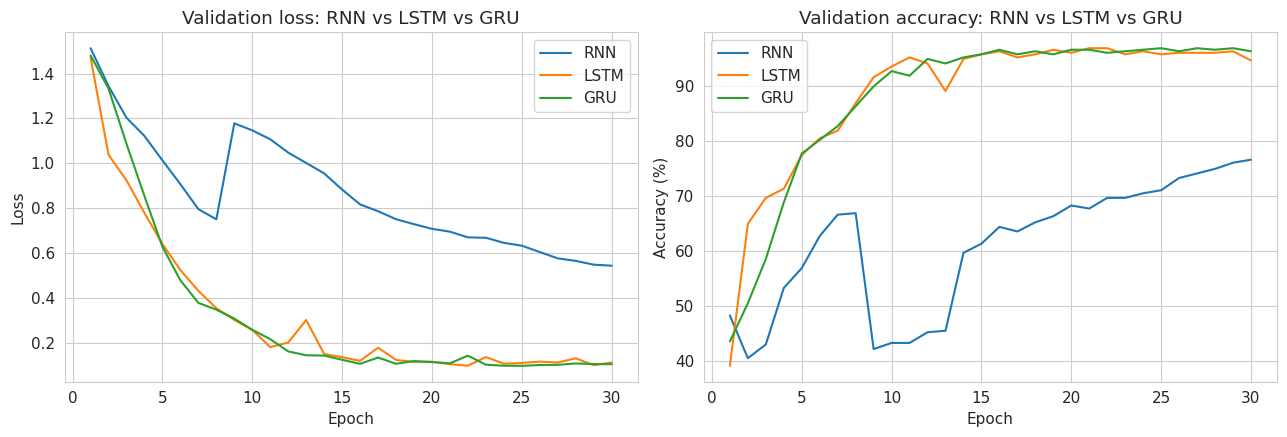

      Parameters  Training time (s)  Final train acc (%)  Final val acc (%)  Best val acc (%)
RNN       1974.0               24.5                78.57              76.67             76.67
LSTM      6006.0               19.8                93.99              94.72             96.94
GRU       4758.0               19.8                96.61              96.39             96.94


In [8]:
# ============================================================
# BLOCK 7: Train LSTM and GRU, plot curves, overlay comparison
# ============================================================

# Warm-up for GRU (RNN and LSTM were warmed up in Block 6), so its timing is fair
_ = build_model("GRU").fit(X_train[:64], y_train[:64], epochs=1, batch_size=32, verbose=0)

# ---------- LSTM ----------
build_model("LSTM").summary()
train_model("LSTM")
print(f"\nFinal LSTM train acc: {histories['LSTM']['accuracy'][-1]*100:.2f}% | "
      f"val acc: {histories['LSTM']['val_accuracy'][-1]*100:.2f}%")
plot_history("LSTM")

# ---------- GRU ----------
build_model("GRU").summary()
train_model("GRU")
print(f"\nFinal GRU  train acc: {histories['GRU']['accuracy'][-1]*100:.2f}% | "
      f"val acc: {histories['GRU']['val_accuracy'][-1]*100:.2f}%")
plot_history("GRU")

# ---------- Overlay: validation curves of all three models ----------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for kind in ["RNN", "LSTM", "GRU"]:
    h = histories[kind]
    ep = np.arange(1, len(h["val_loss"]) + 1)
    ax[0].plot(ep, h["val_loss"], label=kind)
    ax[1].plot(ep, np.array(h["val_accuracy"]) * 100, label=kind)
ax[0].set(title="Validation loss: RNN vs LSTM vs GRU", xlabel="Epoch", ylabel="Loss")
ax[1].set(title="Validation accuracy: RNN vs LSTM vs GRU", xlabel="Epoch", ylabel="Accuracy (%)")
for a in ax:
    a.legend()
plt.tight_layout()
plt.show()

# ---------- Quick summary of what has been recorded so far ----------
summary = pd.DataFrame({
    k: {"Parameters": results[k]["params"],
        "Training time (s)": round(results[k]["train_time_s"], 1),
        "Final train acc (%)": round(histories[k]["accuracy"][-1] * 100, 2),
        "Final val acc (%)":   round(histories[k]["val_accuracy"][-1] * 100, 2),
        "Best val acc (%)":    round(max(histories[k]["val_accuracy"]) * 100, 2)}
    for k in ["RNN", "LSTM", "GRU"]
}).T
print(summary.to_string())

                         RNN     LSTM      GRU
Accuracy (%)           77.78    94.17    95.00
Macro Precision (%)    78.17    94.38    95.01
Macro Recall (%)       77.78    94.17    95.00
Macro F1 (%)           77.69    94.17    95.00
Parameters           1974.00  6006.00  4758.00
Training Time (s)      24.50    19.81    19.76


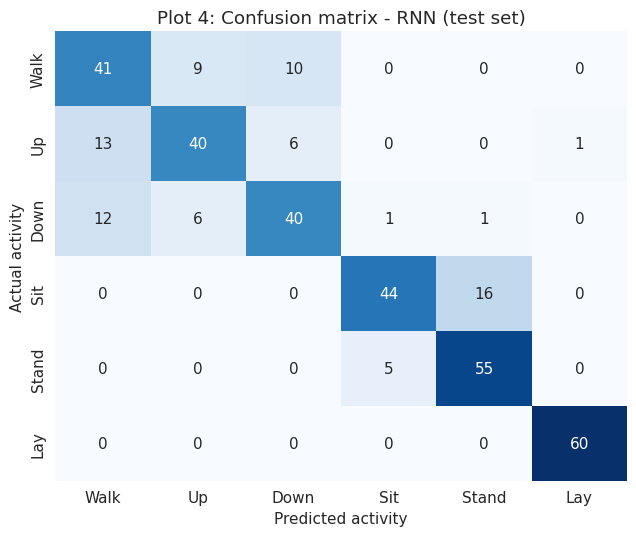

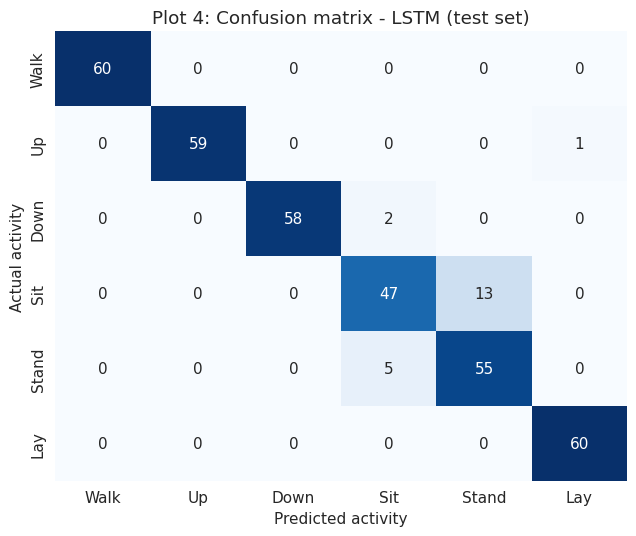

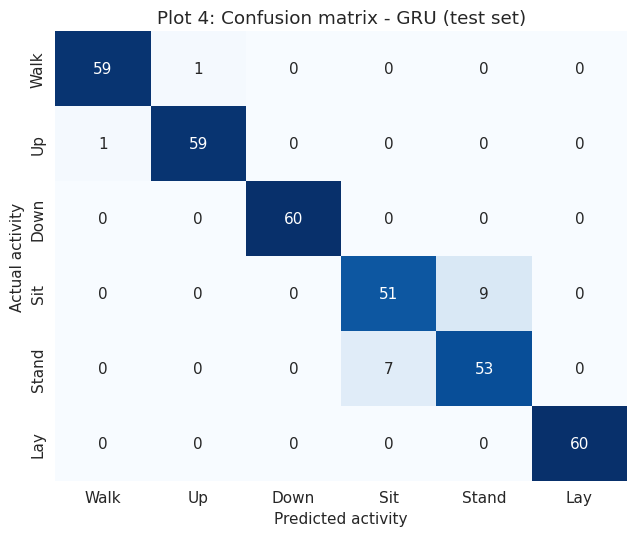


Per-activity recall (%):
                      RNN   LSTM    GRU
WALKING              68.3  100.0   98.3
WALKING_UPSTAIRS     66.7   98.3   98.3
WALKING_DOWNSTAIRS   66.7   96.7  100.0
SITTING              73.3   78.3   85.0
STANDING             91.7   91.7   88.3
LAYING              100.0  100.0  100.0

RNN - most frequent errors:
  SITTING -> STANDING: 16 windows
  WALKING_UPSTAIRS -> WALKING: 13 windows
  WALKING_DOWNSTAIRS -> WALKING: 12 windows
  Total misclassified: 80 of 360

LSTM - most frequent errors:
  SITTING -> STANDING: 13 windows
  STANDING -> SITTING: 5 windows
  WALKING_DOWNSTAIRS -> SITTING: 2 windows
  Total misclassified: 21 of 360

GRU - most frequent errors:
  SITTING -> STANDING: 9 windows
  STANDING -> SITTING: 7 windows
  WALKING -> WALKING_UPSTAIRS: 1 windows
  Total misclassified: 18 of 360


In [9]:
# ============================================================
# BLOCK 8: Test-set evaluation + confusion matrices (Plot 4)
# ============================================================

def evaluate_model(tag, X_te=X_test, y_te=y_test):
    """Evaluate one trained model on the test set and store the metrics."""
    y_pred = models[tag].predict(X_te, verbose=0).argmax(axis=1)
    results[tag].update({
        "accuracy":  accuracy_score(y_te, y_pred) * 100,
        "precision": precision_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "recall":    recall_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "f1":        f1_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "y_pred":    y_pred,
        "cm":        confusion_matrix(y_te, y_pred, labels=range(6)),
    })


for tag in ["RNN", "LSTM", "GRU"]:
    evaluate_model(tag)

# ---------- Results table (fills the table in Section 14) ----------
results_df = pd.DataFrame({
    tag: {
        "Accuracy (%)":        results[tag]["accuracy"],
        "Macro Precision (%)": results[tag]["precision"],
        "Macro Recall (%)":    results[tag]["recall"],
        "Macro F1 (%)":        results[tag]["f1"],
        "Parameters":          results[tag]["params"],
        "Training Time (s)":   results[tag]["train_time_s"],
    } for tag in ["RNN", "LSTM", "GRU"]
})
print(results_df.round(2).to_string())

# ---------- Plot 4: one confusion matrix per model ----------
short = ["Walk", "Up", "Down", "Sit", "Stand", "Lay"]
for tag in ["RNN", "LSTM", "GRU"]:
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(results[tag]["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=short, yticklabels=short, cbar=False)
    plt.title(f"Plot 4: Confusion matrix - {tag} (test set)")
    plt.xlabel("Predicted activity")
    plt.ylabel("Actual activity")
    plt.tight_layout()
    plt.show()

# ---------- Numbers to support your confusion-matrix inference ----------
# Per-class recall = correct predictions of that class / number of windows of that class
recall_df = pd.DataFrame({
    tag: results[tag]["cm"].diagonal() / results[tag]["cm"].sum(axis=1) * 100
    for tag in ["RNN", "LSTM", "GRU"]
}, index=ACTIVITY_NAMES)
print("\nPer-activity recall (%):")
print(recall_df.round(1).to_string())

# Most frequent confusions (actual -> predicted), off-diagonal cells only
for tag in ["RNN", "LSTM", "GRU"]:
    cm = results[tag]["cm"].copy()
    np.fill_diagonal(cm, 0)
    top = np.dstack(np.unravel_index(np.argsort(-cm.ravel())[:3], cm.shape))[0]
    print(f"\n{tag} - most frequent errors:")
    for a, p in top:
        if cm[a, p] > 0:
            print(f"  {ACTIVITY_NAMES[a]} -> {ACTIVITY_NAMES[p]}: {cm[a, p]} windows")
    print(f"  Total misclassified: {cm.sum()} of {len(y_test)}")

                     RNN   LSTM    GRU
Hidden state         Yes    Yes    Yes
Cell state            No    Yes     No
Forget gate           No    Yes     No
Input gate            No    Yes     No
Output gate           No    Yes     No
Update gate           No     No    Yes
Reset gate            No     No    Yes
Parameters         1,974  6,006  4,758
Training time (s)   24.5   19.8   19.8
Test F1-score (%)  77.69  94.17  95.00


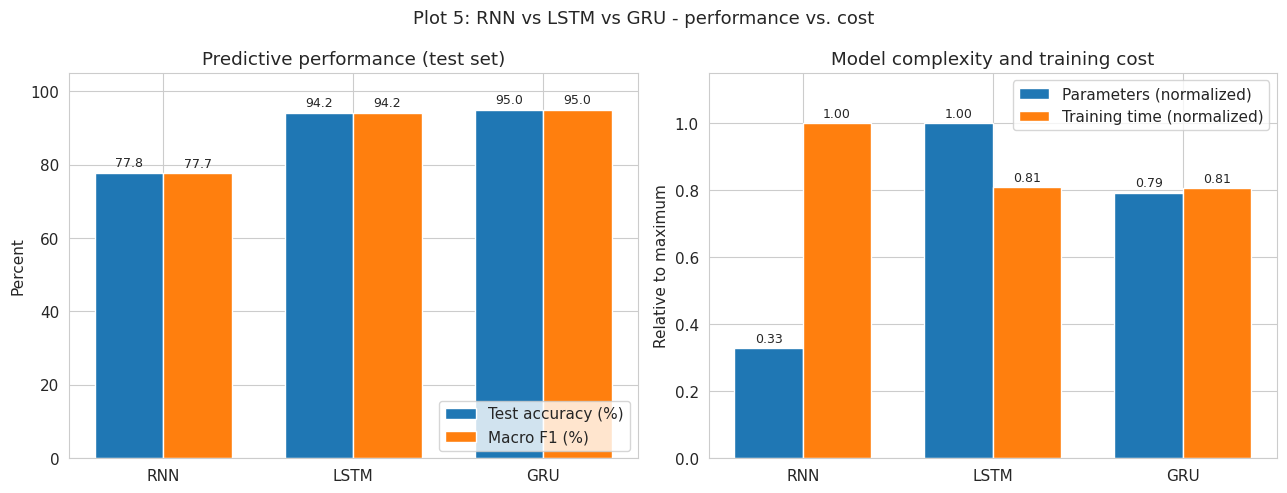


       Test F1 (%)  Parameters  F1 per 1,000 params  Extra F1 vs RNN (pts)  Extra params vs RNN
RNN         77.69        1974                39.35                   0.00                    0
LSTM        94.17        6006                15.68                  16.49                 4032
GRU         95.00        4758                19.97                  17.31                 2784


In [10]:
# ============================================================
# BLOCK 9: Section 16 comparison table + Plot 5
# ============================================================

kinds = ["RNN", "LSTM", "GRU"]

# ---------- Comparison table (Section 16) ----------
comparison = pd.DataFrame({
    "Hidden state":  ["Yes", "Yes", "Yes"],
    "Cell state":    ["No",  "Yes", "No"],
    "Forget gate":   ["No",  "Yes", "No"],
    "Input gate":    ["No",  "Yes", "No"],
    "Output gate":   ["No",  "Yes", "No"],
    "Update gate":   ["No",  "No",  "Yes"],
    "Reset gate":    ["No",  "No",  "Yes"],
    "Parameters":    [f"{results[k]['params']:,}" for k in kinds],
    "Training time (s)": [f"{results[k]['train_time_s']:.1f}" for k in kinds],
    "Test F1-score (%)": [f"{results[k]['f1']:.2f}" for k in kinds],
}, index=kinds).T
comparison.columns = kinds
print(comparison.to_string())

# ---------- Plot 5: performance vs. cost ----------
acc = [results[k]["accuracy"] for k in kinds]
f1  = [results[k]["f1"] for k in kinds]
params = np.array([results[k]["params"] for k in kinds], dtype=float)
times  = np.array([results[k]["train_time_s"] for k in kinds])
params_norm = params / params.max()      # 1.0 = largest model
times_norm  = times / times.max()        # 1.0 = slowest model

x = np.arange(len(kinds))
w = 0.36
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Left: predictive performance
b1 = ax[0].bar(x - w/2, acc, w, label="Test accuracy (%)")
b2 = ax[0].bar(x + w/2, f1,  w, label="Macro F1 (%)")
ax[0].set(title="Predictive performance (test set)", ylabel="Percent", ylim=(0, 105))
ax[0].set_xticks(x); ax[0].set_xticklabels(kinds)
for bars in (b1, b2):
    ax[0].bar_label(bars, fmt="%.1f", padding=2, fontsize=9)
ax[0].legend(loc="lower right")

# Right: computational cost (normalized, 1.0 = largest)
b3 = ax[1].bar(x - w/2, params_norm, w, label="Parameters (normalized)")
b4 = ax[1].bar(x + w/2, times_norm,  w, label="Training time (normalized)")
ax[1].set(title="Model complexity and training cost", ylabel="Relative to maximum", ylim=(0, 1.15))
ax[1].set_xticks(x); ax[1].set_xticklabels(kinds)
for bars in (b3, b4):
    ax[1].bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
ax[1].legend(loc="upper right")

plt.suptitle("Plot 5: RNN vs LSTM vs GRU - performance vs. cost", fontsize=13)
plt.tight_layout()
plt.show()

# ---------- Efficiency view: how much F1 does each model buy per parameter? ----------
eff = pd.DataFrame({
    "Test F1 (%)": f1,
    "Parameters": params.astype(int),
    "F1 per 1,000 params": np.array(f1) / (params / 1000),
    "Extra F1 vs RNN (pts)": np.array(f1) - f1[0],
    "Extra params vs RNN": (params - params[0]).astype(int),
}, index=kinds)
print("\n", eff.round(2).to_string())

In [13]:
# ============================================================
# BLOCK 11 (v2): UCF101 subset - build manifest from filenames, download clips
# ============================================================
import ssl
import urllib.error
from concurrent.futures import ThreadPoolExecutor

UCF_ROOT  = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
VIDEO_DIR = Path.cwd() / "ucf101_videos"
VIDEO_DIR.mkdir(exist_ok=True)

CLASSES = ["Basketball", "Biking", "TennisSwing", "WalkingWithDog", "JumpRope"]

# Split by GROUP number (g01-g25), so near-duplicate scenes never span train/val/test
SPLIT_GROUPS    = {"test": range(1, 6), "val": range(6, 11), "train": range(11, 26)}
CLIPS_PER_GROUP = {"train": 2, "val": 3, "test": 3}

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                         "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"}


def open_url(url):
    req = urllib.request.Request(url, headers=HEADERS)
    try:
        return urllib.request.urlopen(req, timeout=60)
    except urllib.error.HTTPError:
        raise                                   # 403/404 are server answers; don't retry
    except Exception:                           # certificate problem -> retry unverified
        return urllib.request.urlopen(req, context=ssl._create_unverified_context(), timeout=60)


# ---------- 0. Fail fast: can we download a single clip at all? ----------
try:
    with open_url(UCF_ROOT + "v_Biking_g01_c01.avi") as r:
        test_bytes = r.read()
    print(f"Test download OK ({len(test_bytes)/1e3:.0f} KB)")
except Exception as e:
    raise RuntimeError(f"Test download failed: {e}\n"
                       "The server is refusing this notebook. Use the Kaggle 'Add Data' fallback.")

# ---------- 1. Build the manifest directly from filenames ----------
rows = []
for label, cls in enumerate(CLASSES):
    for split, groups in SPLIT_GROUPS.items():
        for g in groups:
            for c in range(1, CLIPS_PER_GROUP[split] + 1):
                fname = f"v_{cls}_g{g:02d}_c{c:02d}.avi"
                rows.append(dict(fname=fname, cls=cls, label=label, group=g, clip=c,
                                 split=split, path=str(VIDEO_DIR / fname)))
manifest = pd.DataFrame(rows)


# ---------- 2. Download ----------
def fetch(fname):
    dest = VIDEO_DIR / fname
    if dest.exists() and dest.stat().st_size > 0:
        return True
    try:
        with open_url(UCF_ROOT + fname) as r, open(dest, "wb") as f:
            f.write(r.read())
        return True
    except Exception:
        return False

print(f"Downloading {len(manifest)} clips...")
with ThreadPoolExecutor(max_workers=8) as ex:
    manifest["ok"] = list(ex.map(fetch, manifest["fname"]))

failed = manifest[~manifest["ok"]]
print(f"Failed downloads: {len(failed)}")
if len(failed):
    print(failed.groupby("cls").size().rename("failed clips per class").to_string())
    print("If one class fails completely, its name is probably wrong - change it in CLASSES.")

manifest = manifest[manifest["ok"]].drop(columns="ok").reset_index(drop=True)
manifest.to_csv(VIDEO_DIR / "manifest.csv", index=False)

# ---------- 3. Verify ----------
print("\nVideos per class and split:")
print(pd.crosstab(manifest["cls"], manifest["split"])[["train", "val", "test"]])
print("\nSize on disk: %.0f MB" % (sum(p.stat().st_size for p in VIDEO_DIR.glob("*.avi")) / 1e6))

cap = cv2.VideoCapture(manifest["path"][0])
print(f"\nExample video: {manifest['fname'][0]}")
print("  frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
      "| fps:", cap.get(cv2.CAP_PROP_FPS),
      "| size:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), "x", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
cap.release()

Test download OK (368 KB)
Failed downloads: 0

Videos per class and split:
split           train  val  test
cls                             
Basketball         30   15    15
Biking             30   15    15
JumpRope           30   15    15
TennisSwing        30   15    15
WalkingWithDog     30   15    15

Size on disk: 156 MB

Example video: v_Basketball_g01_c01.avi
  frames: 141 | fps: 29.97002997002997 | size: 320 x 240


T=32   RNN   F1=75.90  time=17.3s
T=32   LSTM  F1=92.49  time=15.7s
T=32   GRU   F1=92.46  time=15.3s
T=64   RNN   F1=74.98  time=18.8s
T=64   LSTM  F1=93.06  time=17.2s
T=64   GRU   F1=95.27  time=16.9s

Test macro F1 vs. sequence length
                 RNN F1 (%)  LSTM F1 (%)  GRU F1 (%)
Sequence length                                     
32                    75.90        92.49       92.46
64                    74.98        93.06       95.27
128                   77.69        94.17       95.00

Training time vs. sequence length
                 RNN time (s)  LSTM time (s)  GRU time (s)
Sequence length                                           
32                       17.3           15.7          15.3
64                       18.8           17.2          16.9
128                      24.5           19.8          19.8

Parameters (do they change with T?): {'RNN': [1974], 'LSTM': [6006], 'GRU': [4758]}


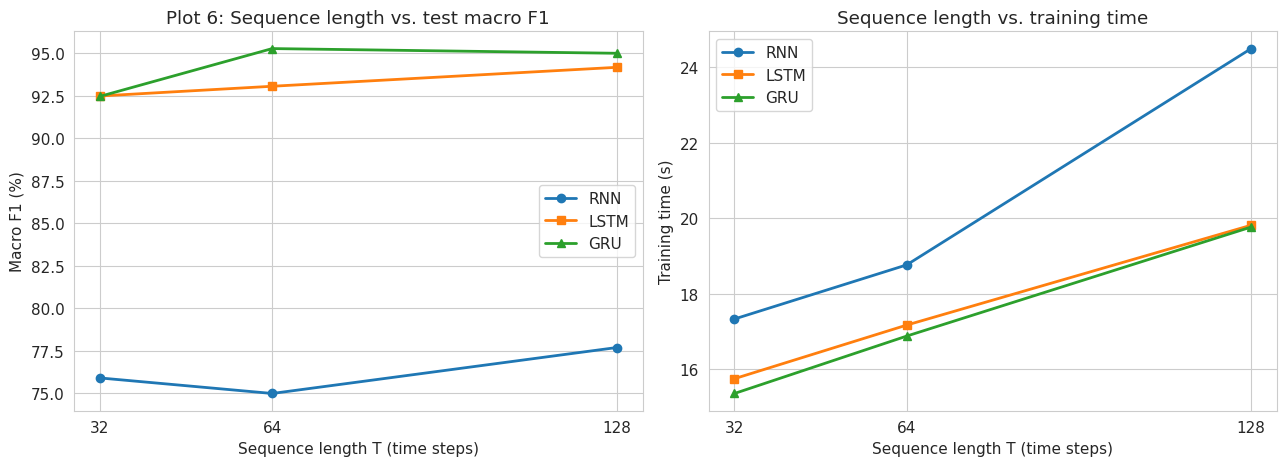

In [11]:
# ============================================================
# BLOCK 10: Effect of sequence length (T = 32, 64, 128) + Plot 6
# ============================================================

SEQ_LENGTHS = [32, 64, 128]
length_results = {T: {} for T in SEQ_LENGTHS}


def run_length_experiment(kind, T):
    """Train one model on the first T time steps of every window; evaluate on the test set."""
    Xtr = np.ascontiguousarray(X_train[:, :T, :])
    Xv  = np.ascontiguousarray(X_val[:, :T, :])
    Xte = np.ascontiguousarray(X_test[:, :T, :])

    # Warm-up for this new input shape, so the timing below excludes one-time tracing cost
    build_model(kind, seq_len=T).fit(Xtr[:64], y_train[:64], epochs=1,
                                     batch_size=BATCH_SIZE, verbose=0)

    model = build_model(kind, seq_len=T)
    start = time.time()
    model.fit(Xtr, y_train, validation_data=(Xv, y_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    elapsed = time.time() - start

    y_pred = model.predict(Xte, verbose=0).argmax(axis=1)
    return {
        "acc":    accuracy_score(y_test, y_pred) * 100,
        "f1":     f1_score(y_test, y_pred, average="macro", zero_division=0) * 100,
        "time_s": elapsed,
        "params": model.count_params(),
    }


for T in SEQ_LENGTHS:
    for kind in ["RNN", "LSTM", "GRU"]:
        if T == SEQ_LENGTHS[-1]:
            # T = 128 was already trained and evaluated in Blocks 6-8 -> reuse it
            length_results[T][kind] = {"acc": results[kind]["accuracy"], "f1": results[kind]["f1"],
                                       "time_s": results[kind]["train_time_s"],
                                       "params": results[kind]["params"]}
        else:
            length_results[T][kind] = run_length_experiment(kind, T)
            print(f"T={T:<4} {kind:<5} F1={length_results[T][kind]['f1']:.2f}  "
                  f"time={length_results[T][kind]['time_s']:.1f}s")

# ---------- Table from Section 17 ----------
kinds = ["RNN", "LSTM", "GRU"]
f1_table = pd.DataFrame({k: [length_results[T][k]["f1"] for T in SEQ_LENGTHS] for k in kinds},
                        index=pd.Index(SEQ_LENGTHS, name="Sequence length"))
f1_table.columns = [f"{k} F1 (%)" for k in kinds]
print("\nTest macro F1 vs. sequence length")
print(f1_table.round(2).to_string())

time_table = pd.DataFrame({k: [length_results[T][k]["time_s"] for T in SEQ_LENGTHS] for k in kinds},
                          index=pd.Index(SEQ_LENGTHS, name="Sequence length"))
time_table.columns = [f"{k} time (s)" for k in kinds]
print("\nTraining time vs. sequence length")
print(time_table.round(1).to_string())

print("\nParameters (do they change with T?):",
      {k: sorted({length_results[T][k]['params'] for T in SEQ_LENGTHS}) for k in kinds})

# ---------- Plot 6 (+ training time panel for Additional Exercise 5) ----------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for k, marker in zip(kinds, ["o", "s", "^"]):
    ax[0].plot(SEQ_LENGTHS, [length_results[T][k]["f1"] for T in SEQ_LENGTHS],
               marker=marker, lw=2, label=k)
    ax[1].plot(SEQ_LENGTHS, [length_results[T][k]["time_s"] for T in SEQ_LENGTHS],
               marker=marker, lw=2, label=k)
ax[0].set(title="Plot 6: Sequence length vs. test macro F1", xlabel="Sequence length T (time steps)",
          ylabel="Macro F1 (%)")
ax[1].set(title="Sequence length vs. training time", xlabel="Sequence length T (time steps)",
          ylabel="Training time (s)")
for a in ax:
    a.set_xticks(SEQ_LENGTHS)
    a.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# BLOCK 11 (v2): UCF101 subset - build manifest from filenames, download clips
# ============================================================
import ssl
import urllib.error
from concurrent.futures import ThreadPoolExecutor

UCF_ROOT  = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
VIDEO_DIR = Path.cwd() / "ucf101_videos"
VIDEO_DIR.mkdir(exist_ok=True)

CLASSES = ["Basketball", "Biking", "TennisSwing", "WalkingWithDog", "JumpRope"]

# Split by GROUP number (g01-g25), so near-duplicate scenes never span train/val/test
SPLIT_GROUPS    = {"test": range(1, 6), "val": range(6, 11), "train": range(11, 26)}
CLIPS_PER_GROUP = {"train": 2, "val": 3, "test": 3}

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                         "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"}


def open_url(url):
    req = urllib.request.Request(url, headers=HEADERS)
    try:
        return urllib.request.urlopen(req, timeout=60)
    except urllib.error.HTTPError:
        raise                                   # 403/404 are server answers; don't retry
    except Exception:                           # certificate problem -> retry unverified
        return urllib.request.urlopen(req, context=ssl._create_unverified_context(), timeout=60)


# ---------- 0. Fail fast: can we download a single clip at all? ----------
try:
    with open_url(UCF_ROOT + "v_Biking_g01_c01.avi") as r:
        test_bytes = r.read()
    print(f"Test download OK ({len(test_bytes)/1e3:.0f} KB)")
except Exception as e:
    raise RuntimeError(f"Test download failed: {e}\n"
                       "The server is refusing this notebook. Use the Kaggle 'Add Data' fallback.")

# ---------- 1. Build the manifest directly from filenames ----------
rows = []
for label, cls in enumerate(CLASSES):
    for split, groups in SPLIT_GROUPS.items():
        for g in groups:
            for c in range(1, CLIPS_PER_GROUP[split] + 1):
                fname = f"v_{cls}_g{g:02d}_c{c:02d}.avi"
                rows.append(dict(fname=fname, cls=cls, label=label, group=g, clip=c,
                                 split=split, path=str(VIDEO_DIR / fname)))
manifest = pd.DataFrame(rows)


# ---------- 2. Download ----------
def fetch(fname):
    dest = VIDEO_DIR / fname
    if dest.exists() and dest.stat().st_size > 0:
        return True
    try:
        with open_url(UCF_ROOT + fname) as r, open(dest, "wb") as f:
            f.write(r.read())
        return True
    except Exception:
        return False

print(f"Downloading {len(manifest)} clips...")
with ThreadPoolExecutor(max_workers=8) as ex:
    manifest["ok"] = list(ex.map(fetch, manifest["fname"]))

failed = manifest[~manifest["ok"]]
print(f"Failed downloads: {len(failed)}")
if len(failed):
    print(failed.groupby("cls").size().rename("failed clips per class").to_string())
    print("If one class fails completely, its name is probably wrong - change it in CLASSES.")

manifest = manifest[manifest["ok"]].drop(columns="ok").reset_index(drop=True)
manifest.to_csv(VIDEO_DIR / "manifest.csv", index=False)

# ---------- 3. Verify ----------
print("\nVideos per class and split:")
print(pd.crosstab(manifest["cls"], manifest["split"])[["train", "val", "test"]])
print("\nSize on disk: %.0f MB" % (sum(p.stat().st_size for p in VIDEO_DIR.glob("*.avi")) / 1e6))

cap = cv2.VideoCapture(manifest["path"][0])
print(f"\nExample video: {manifest['fname'][0]}")
print("  frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
      "| fps:", cap.get(cv2.CAP_PROP_FPS),
      "| size:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), "x", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
cap.release()

Test download OK (368 KB)
Failed downloads: 0

Videos per class and split:
split           train  val  test
cls                             
Basketball         30   15    15
Biking             30   15    15
JumpRope           30   15    15
TennisSwing        30   15    15
WalkingWithDog     30   15    15

Size on disk: 156 MB

Example video: v_Basketball_g01_c01.avi
  frames: 141 | fps: 29.97002997002997 | size: 320 x 240


Frames per video, by class:
                min  median  max
cls                             
Basketball       53   120.0  528
Biking          101   201.0  599
JumpRope        198   432.5  623
TennisSwing      62   134.5  335
WalkingWithDog   93   240.0  240

Video: v_Basketball_g01_c01.avi  |  total frames: 141
Chosen frame indices: [  0  15  31  46  62  77  93 108 124 140]
Sampled tensor shape: (10, 224, 224, 3) | dtype: uint8 | sampling time: 0.09 s


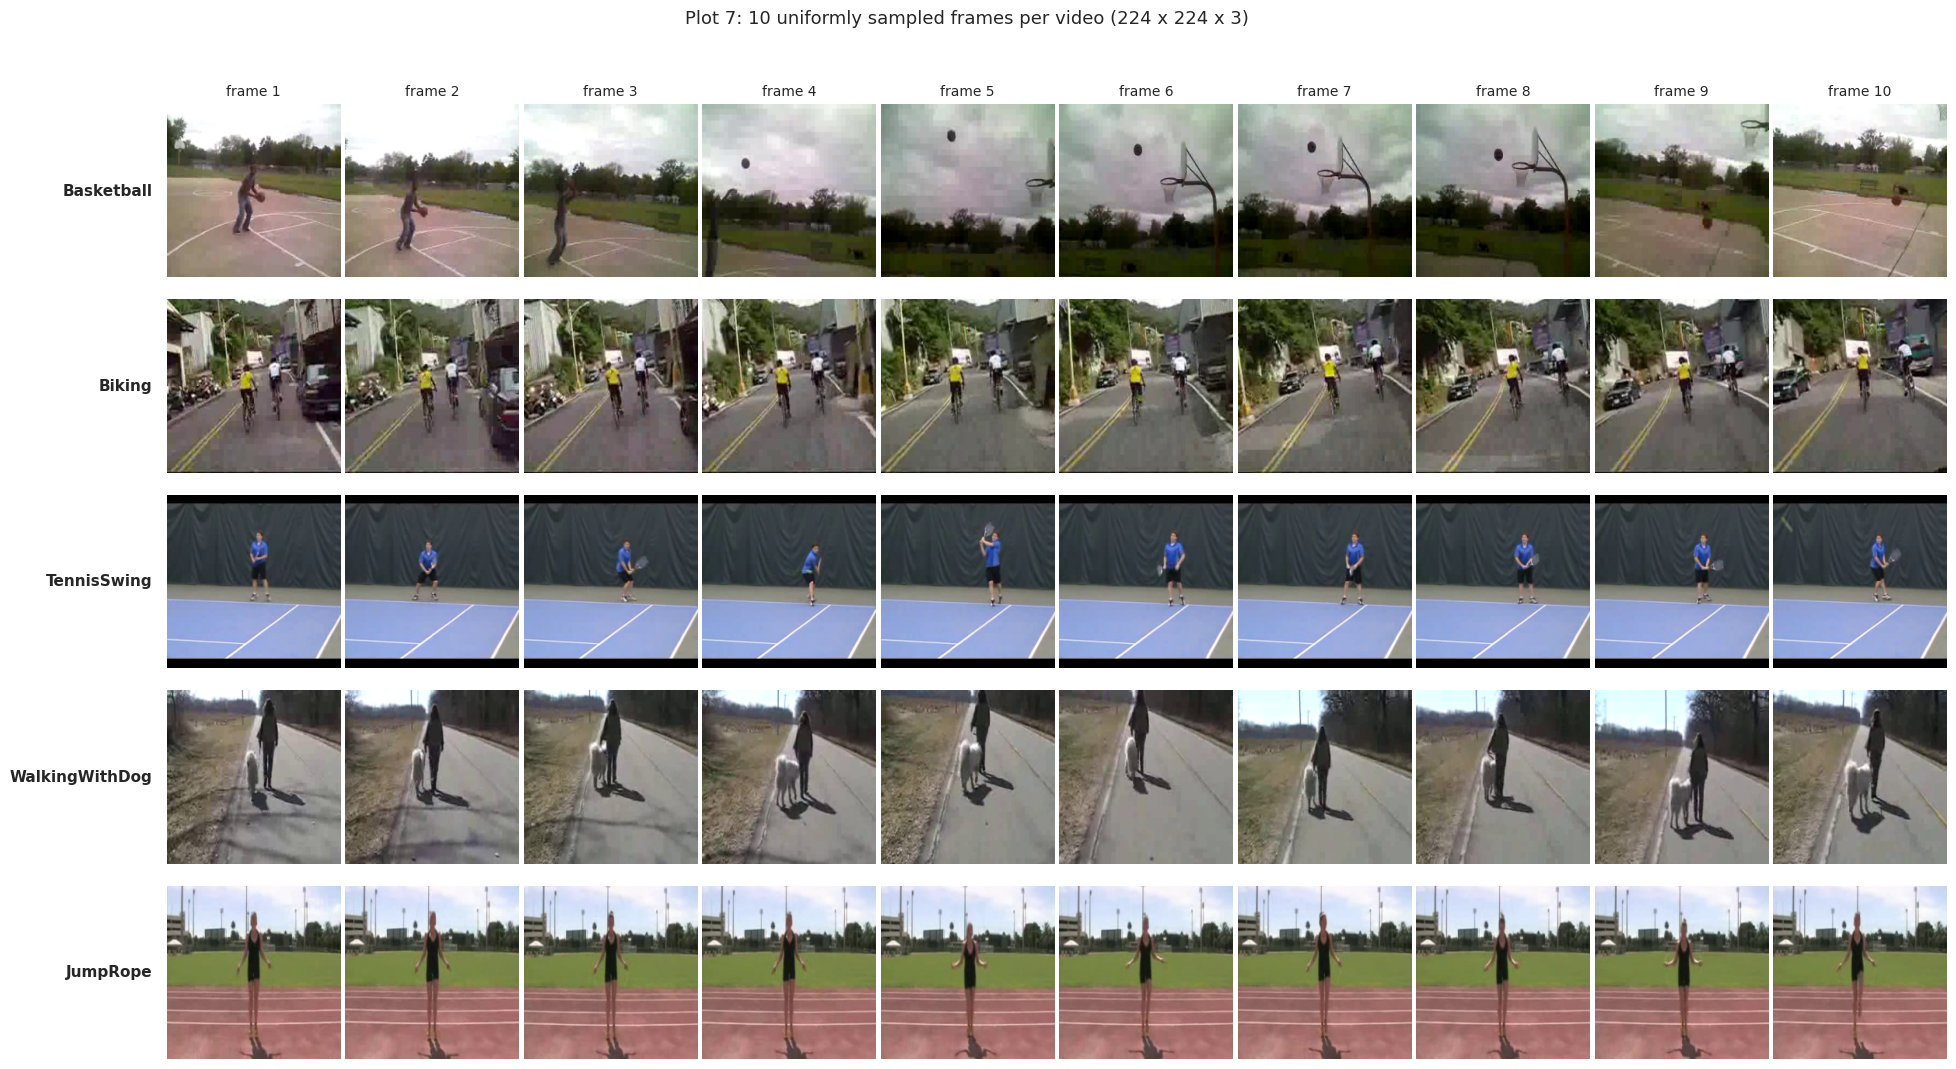

In [15]:
# ============================================================
# BLOCK 12: Sample 10 frames per video, resize to 224x224x3, Plot 7
# ============================================================

N_FRAMES = 10
IMG_SIZE = 224


def sample_frames(path, n_frames=N_FRAMES, size=IMG_SIZE):
    """Read a video, pick n_frames evenly spaced frames, resize each to size x size (RGB).
    Returns: frames (n_frames, size, size, 3) uint8, chosen indices, total frames in video."""
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()
    if len(frames) == 0:
        raise ValueError(f"No frames could be read from {path}")

    idx = np.linspace(0, len(frames) - 1, n_frames).astype(int)      # uniform sampling
    out = [cv2.resize(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB), (size, size),
                      interpolation=cv2.INTER_AREA) for i in idx]     # BGR -> RGB, resize
    return np.stack(out).astype(np.uint8), idx, len(frames)


# ---------- Sanity check: video lengths (frames per video) ----------
counts = []
for p in manifest["path"]:
    cap = cv2.VideoCapture(p)
    counts.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    cap.release()
manifest["n_frames"] = counts
print("Frames per video, by class:")
print(manifest.groupby("cls")["n_frames"].agg(["min", "median", "max"]).to_string())

# ---------- One example, with shapes ----------
t0 = time.time()
frames, idx, total = sample_frames(manifest["path"][0])
print(f"\nVideo: {manifest['fname'][0]}  |  total frames: {total}")
print("Chosen frame indices:", idx)
print("Sampled tensor shape:", frames.shape, "| dtype:", frames.dtype,
      f"| sampling time: {time.time() - t0:.2f} s")

# ---------- Plot 7: sampled frames, one train video per class ----------
fig, axes = plt.subplots(len(CLASSES), N_FRAMES, figsize=(2 * N_FRAMES, 2.2 * len(CLASSES)))
for r, cls in enumerate(CLASSES):
    row = manifest[(manifest["cls"] == cls) & (manifest["split"] == "train")].iloc[0]
    fr, _, _ = sample_frames(row["path"])
    for c in range(N_FRAMES):
        axes[r, c].imshow(fr[c])
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(f"frame {c + 1}", fontsize=10)
    axes[r, 0].text(-0.08, 0.5, cls, transform=axes[r, 0].transAxes,
                    ha="right", va="center", fontsize=11, fontweight="bold")
fig.suptitle("Plot 7: 10 uniformly sampled frames per video (224 x 224 x 3)", fontsize=13)
plt.subplots_adjust(left=0.10, right=0.99, top=0.90, bottom=0.02, wspace=0.03, hspace=0.05)
plt.show()

In [16]:
# ============================================================
# BLOCK 13: MobileNetV2 feature extraction (frozen CNN)
# ============================================================

# ---------- 1. Pretrained CNN without the classification head ----------
base_cnn = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False,       # remove the ImageNet classifier
                       weights="imagenet",      # pretrained weights
                       pooling="avg")           # global average pooling -> one vector per frame
base_cnn.trainable = False                      # frozen: the CNN is never trained here

D = base_cnn.output_shape[-1]
print("CNN output per frame :", base_cnn.output_shape, "-> feature dimension D =", D)
print(f"CNN parameters       : {base_cnn.count_params():,} (all frozen)")

# ---------- 2. Extract features for every video (cached on disk) ----------
FEAT_FILE = Path.cwd() / "video_features_mobilenetv2.npz"


def extract_features(paths, chunk=16):
    """paths -> features of shape (n_videos, N_FRAMES, D). Processes `chunk` videos at a time."""
    feats = []
    for s in range(0, len(paths), chunk):
        batch = [sample_frames(p)[0] for p in paths[s:s + chunk]]        # list of (10, 224, 224, 3)
        x = np.concatenate(batch, axis=0).astype("float32")              # (chunk*10, 224, 224, 3)
        x = preprocess_input(x)                                          # scale pixels to [-1, 1]
        f = base_cnn.predict(x, batch_size=64, verbose=0)                # (chunk*10, D)
        feats.append(f.reshape(len(batch), N_FRAMES, -1))                # (chunk, 10, D)
        print(f"  processed {min(s + chunk, len(paths))}/{len(paths)} videos", end="\r")
    return np.concatenate(feats)


if FEAT_FILE.exists():
    print("\nLoading cached features...")
    cache = np.load(FEAT_FILE, allow_pickle=True)
    VX_all = cache["X"]
    assert list(cache["fnames"]) == list(manifest["fname"]), "Cache does not match manifest - delete the .npz"
else:
    print("\nExtracting features (decoding video + CNN forward pass)...")
    t0 = time.time()
    VX_all = extract_features(list(manifest["path"]))
    print(f"\nExtraction time: {time.time() - t0:.0f} s")
    np.savez_compressed(FEAT_FILE, X=VX_all, fnames=manifest["fname"].values)

# ---------- 3. Split by the manifest (train / val / test by group) ----------
vy_all = manifest["label"].values.astype(np.int64)
masks = {s: (manifest["split"] == s).values for s in ["train", "val", "test"]}
VX_train, vy_train = VX_all[masks["train"]], vy_all[masks["train"]]
VX_val,   vy_val   = VX_all[masks["val"]],   vy_all[masks["val"]]
VX_test,  vy_test  = VX_all[masks["test"]],  vy_all[masks["test"]]

# ---------- 4. Required observation ----------
print("\nCNN feature dimension D :", D)
print("Tensor shape given to the recurrent network (B, 10, D):")
print("  Training  :", VX_train.shape)
print("  Validation:", VX_val.shape)
print("  Testing   :", VX_test.shape)
print("Number of action classes:", len(CLASSES), CLASSES)

# ---------- 5. Sanity checks ----------
print("\nAny NaN in features:", bool(np.isnan(VX_all).any()))
print(f"Feature range: min={VX_all.min():.3f}, max={VX_all.max():.3f}, mean={VX_all.mean():.3f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN output per frame : (None, 1280) -> feature dimension D = 1280
CNN parameters       : 2,257,984 (all frozen)

Extracting features (decoding video + CNN forward pass)...


2026-09-19 10:09:24.607780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 10:09:24.747395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 10:09:38.063823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 10:09:38.219987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 10:09:38.357313: E external/local_xla/xla/stream_

2026-09-19 10:10:18.280058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 10:10:18.418966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  processed 300/300 videos
Extraction time: 70 s

CNN feature dimension D : 1280
Tensor shape given to the recurrent network (B, 10, D):
  Training  : (150, 10, 1280)
  Validation: (75, 10, 1280)
  Testing   : (75, 10, 1280)
Number of action classes: 5 ['Basketball', 'Biking', 'TennisSwing', 'WalkingWithDog', 'JumpRope']

Any NaN in features: False
Feature range: min=0.000, max=5.551, mean=0.479


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_features (InputLayer)     │ (None, 10, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_lstm (LSTM)                 │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,689 (1.93 MB)

 Trainable params: 168,229 (657.14 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 378,929 (1.45 MB)

 Trainable params: 126,309 (493.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 252,620 (986.80 KB)


           Parameters  Training time (s)  Final train acc (%)  Final val acc (%)  Best val acc (%)  Final val loss
CNN-LSTM    168229.0                7.0                100.0              81.33              84.0          0.6334
CNN-GRU     126309.0                6.7                100.0              80.00              84.0          0.5155

Selected architecture (highest mean val accuracy over last 5 epochs): CNN-LSTM


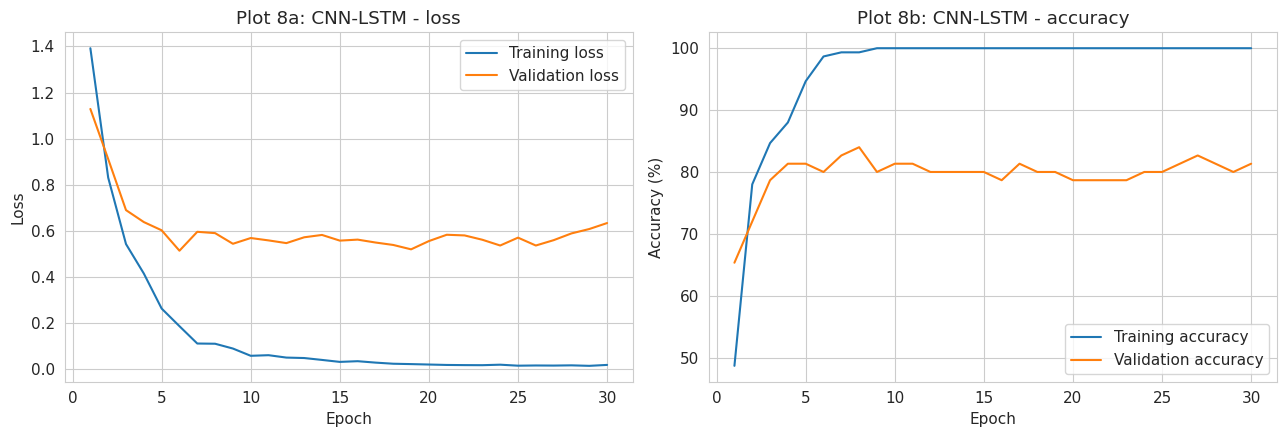

In [17]:
# ============================================================
# BLOCK 14: CNN-LSTM and CNN-GRU on the extracted features (Plot 8)
# ============================================================

NUM_ACTIONS  = len(CLASSES)          # 5
V_UNITS      = 32                    # lab: 32 recurrent units
V_DROPOUT    = 0.3                   # extra regularisation (only 150 training videos)
V_LR         = 1e-3
V_BATCH      = 16                    # smaller batch -> more weight updates on a tiny dataset
V_EPOCHS     = 30

VIDEO_LAYERS = {"CNN-LSTM": LSTM, "CNN-GRU": GRU}
video_results, video_histories, video_models = {}, {}, {}


def build_video_model(kind):
    """(10, D) feature sequence -> LSTM/GRU(32) -> Dropout -> Dense(5, softmax)."""
    keras.utils.set_random_seed(SEED)
    inp = Input(shape=(N_FRAMES, D), name="frame_features")
    x = VIDEO_LAYERS[kind](V_UNITS, name=kind.lower().replace("-", "_"))(inp)
    x = Dropout(V_DROPOUT)(x)
    out = Dense(NUM_ACTIONS, activation="softmax")(x)
    model = Model(inp, out, name=kind.replace("-", "_"))
    model.compile(optimizer=Adam(learning_rate=V_LR),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_video_model(kind):
    build_video_model(kind).fit(VX_train[:32], vy_train[:32], epochs=1, verbose=0)   # warm-up
    model = build_video_model(kind)
    start = time.time()
    hist = model.fit(VX_train, vy_train, validation_data=(VX_val, vy_val),
                     epochs=V_EPOCHS, batch_size=V_BATCH, verbose=0)
    elapsed = time.time() - start
    video_models[kind], video_histories[kind] = model, hist.history
    video_results[kind] = {"params": model.count_params(), "train_time_s": elapsed}
    return model


for kind in ["CNN-LSTM", "CNN-GRU"]:
    m = train_video_model(kind)
    m.summary()

# ---------- Summary and model selection (on VALIDATION accuracy only) ----------
summary_v = pd.DataFrame({
    k: {"Parameters": video_results[k]["params"],
        "Training time (s)": round(video_results[k]["train_time_s"], 1),
        "Final train acc (%)": round(video_histories[k]["accuracy"][-1] * 100, 2),
        "Final val acc (%)":   round(video_histories[k]["val_accuracy"][-1] * 100, 2),
        "Best val acc (%)":    round(max(video_histories[k]["val_accuracy"]) * 100, 2),
        "Final val loss":      round(video_histories[k]["val_loss"][-1], 4)}
    for k in VIDEO_LAYERS}).T
print("\n", summary_v.to_string())

# Mean of the last 5 epochs is less noisy than the last epoch alone (75 val videos = 1.3% per video)
score = {k: np.mean(video_histories[k]["val_accuracy"][-5:]) for k in VIDEO_LAYERS}
SELECTED = max(score, key=score.get)
print(f"\nSelected architecture (highest mean val accuracy over last 5 epochs): {SELECTED}")


# ---------- Plot 8: training / validation curves of the selected model ----------
def plot_video_history(tag):
    h = video_histories[tag]
    ep = np.arange(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(ep, h["loss"], label="Training loss")
    ax[0].plot(ep, h["val_loss"], label="Validation loss")
    ax[0].set(title=f"Plot 8a: {tag} - loss", xlabel="Epoch", ylabel="Loss")
    ax[1].plot(ep, np.array(h["accuracy"]) * 100, label="Training accuracy")
    ax[1].plot(ep, np.array(h["val_accuracy"]) * 100, label="Validation accuracy")
    ax[1].set(title=f"Plot 8b: {tag} - accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for a in ax:
        a.legend()
    plt.tight_layout()
    plt.show()

plot_video_history(SELECTED)

Main model (selected on validation): CNN-LSTM

                       CNN-LSTM    CNN-GRU
Accuracy (%)              85.33      80.00
Macro Precision (%)       86.33      80.02
Macro Recall (%)          85.33      80.00
Macro F1 (%)              85.30      79.94
Trainable parameters  168229.00  126309.00
Training time (s)          6.95       6.71


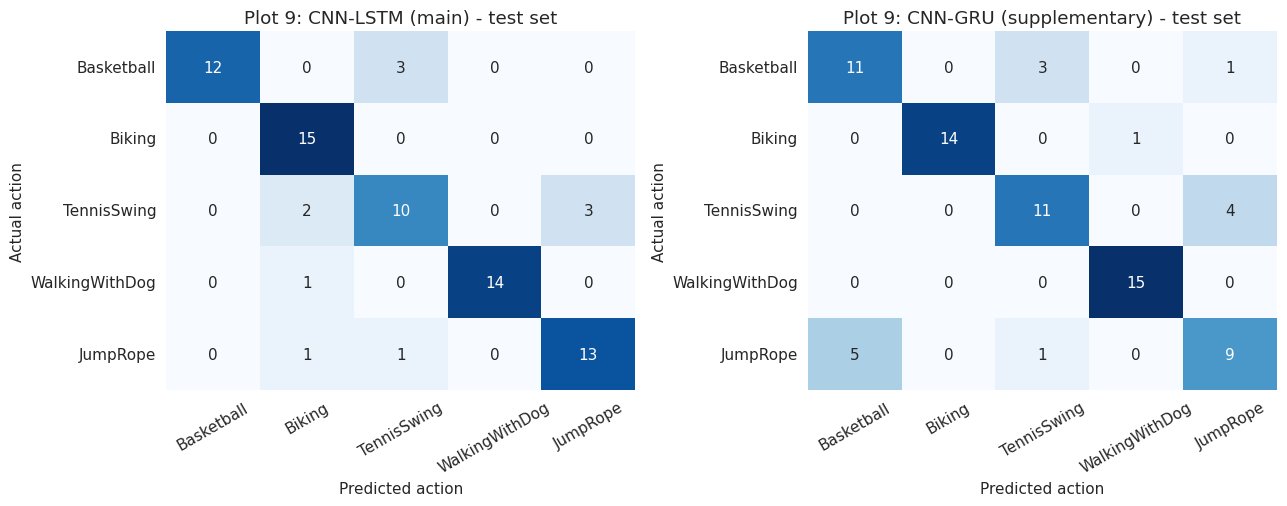


Per-action recall (%):
                CNN-LSTM  CNN-GRU
Basketball          80.0     73.3
Biking             100.0     93.3
TennisSwing         66.7     73.3
WalkingWithDog      93.3    100.0
JumpRope            86.7     60.0

CNN-LSTM - misclassified 11 of 75 test videos
  Basketball -> TennisSwing: 3
  TennisSwing -> Biking: 2
  TennisSwing -> JumpRope: 3
  WalkingWithDog -> Biking: 1
  JumpRope -> Biking: 1
  JumpRope -> TennisSwing: 1

CNN-GRU - misclassified 15 of 75 test videos
  Basketball -> TennisSwing: 3
  Basketball -> JumpRope: 1
  Biking -> WalkingWithDog: 1
  TennisSwing -> JumpRope: 4
  JumpRope -> Basketball: 5
  JumpRope -> TennisSwing: 1

Example predictions (CNN-LSTM):
  v_JumpRope_g05_c02.avi
    Predicted class : JumpRope
    Actual class    : JumpRope
    Confidence      : 0.94   (correct)
  v_WalkingWithDog_g03_c02.avi
    Predicted class : WalkingWithDog
    Actual class    : WalkingWithDog
    Confidence      : 0.91   (correct)
  v_JumpRope_g01_c03.avi
    Pr

In [18]:
# ============================================================
# BLOCK 15: Video test evaluation, Plot 9, example predictions
# ============================================================

def evaluate_video(tag):
    probs  = video_models[tag].predict(VX_test, verbose=0)      # (75, 5) class probabilities
    y_pred = probs.argmax(axis=1)
    video_results[tag].update({
        "accuracy":  accuracy_score(vy_test, y_pred) * 100,
        "precision": precision_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "recall":    recall_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "f1":        f1_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "cm":        confusion_matrix(vy_test, y_pred, labels=range(NUM_ACTIONS)),
        "y_pred":    y_pred,
        "probs":     probs,
    })

for tag in ["CNN-LSTM", "CNN-GRU"]:
    evaluate_video(tag)

# ---------- Test-set metrics ----------
video_df = pd.DataFrame({
    tag: {"Accuracy (%)":        video_results[tag]["accuracy"],
          "Macro Precision (%)": video_results[tag]["precision"],
          "Macro Recall (%)":    video_results[tag]["recall"],
          "Macro F1 (%)":        video_results[tag]["f1"],
          "Trainable parameters": video_results[tag]["params"],
          "Training time (s)":   video_results[tag]["train_time_s"]}
    for tag in ["CNN-LSTM", "CNN-GRU"]})
print(f"Main model (selected on validation): {SELECTED}\n")
print(video_df.round(2).to_string())

# ---------- Plot 9: confusion matrices ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
order = [SELECTED] + [t for t in ["CNN-LSTM", "CNN-GRU"] if t != SELECTED]
for ax, tag in zip(axes, order):
    sns.heatmap(video_results[tag]["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    role = "main" if tag == SELECTED else "supplementary"
    ax.set(title=f"Plot 9: {tag} ({role}) - test set", xlabel="Predicted action", ylabel="Actual action")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# ---------- Per-class recall and most frequent errors ----------
recall_v = pd.DataFrame({
    tag: video_results[tag]["cm"].diagonal() / video_results[tag]["cm"].sum(axis=1) * 100
    for tag in order}, index=CLASSES)
print("\nPer-action recall (%):")
print(recall_v.round(1).to_string())

for tag in order:
    cm = video_results[tag]["cm"].copy()
    np.fill_diagonal(cm, 0)
    print(f"\n{tag} - misclassified {cm.sum()} of {len(vy_test)} test videos")
    for a, p in zip(*np.nonzero(cm)):
        print(f"  {CLASSES[a]} -> {CLASSES[p]}: {cm[a, p]}")

# ---------- Required output format: predicted / actual / confidence ----------
# Confidence = the model's softmax probability for the predicted class (computed, never typed in)
main = video_results[SELECTED]
test_meta = manifest[masks["test"]].reset_index(drop=True)
rng_v = np.random.default_rng(SEED)
show = rng_v.choice(len(vy_test), size=8, replace=False)

print(f"\nExample predictions ({SELECTED}):")
for i in show:
    pred, true = main["y_pred"][i], vy_test[i]
    print(f"  {test_meta['fname'][i]}\n"
          f"    Predicted class : {CLASSES[pred]}\n"
          f"    Actual class    : {CLASSES[true]}\n"
          f"    Confidence      : {main['probs'][i, pred]:.2f}   "
          f"{'(correct)' if pred == true else '(WRONG)'}")

# ---------- Wrong predictions: how confident was the model? ----------
wrong = np.where(main["y_pred"] != vy_test)[0]
correct = np.where(main["y_pred"] == vy_test)[0]
print(f"\nMean confidence when correct: {main['probs'][correct, main['y_pred'][correct]].mean():.2f}")
if len(wrong):
    print(f"Mean confidence when wrong  : {main['probs'][wrong, main['y_pred'][wrong]].mean():.2f}")
    print("\nMisclassified test videos:")
    for i in wrong:
        print(f"  {test_meta['fname'][i]:<34} actual={CLASSES[vy_test[i]]:<15} "
              f"predicted={CLASSES[main['y_pred'][i]]:<15} conf={main['probs'][i, main['y_pred'][i]]:.2f}")

Train (7000, 6) | Val (1500, 6) | Test (1500, 6)
Example  input: [1 7 6 4 4 8] | decoder input: [0 8 4 4 6 7] | target: [8 4 4 6 7 1]


Model: "seq2seq_reverse"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 6, 16)     │        160 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 6, 16)     │        160 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     74,240 │ enc_embedding[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 6, 128)    │     74,240 │ dec_embedding[0]… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6, 10)     │      1,290 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,090 (586.29 KB)

 Trainable params: 150,090 (586.29 KB)

 Non-trainable params: 0 (0.00 B)


Training time: 42.6 s | parameters: 150,090
Final training loss: 0.0004 | final validation loss: 0.0006


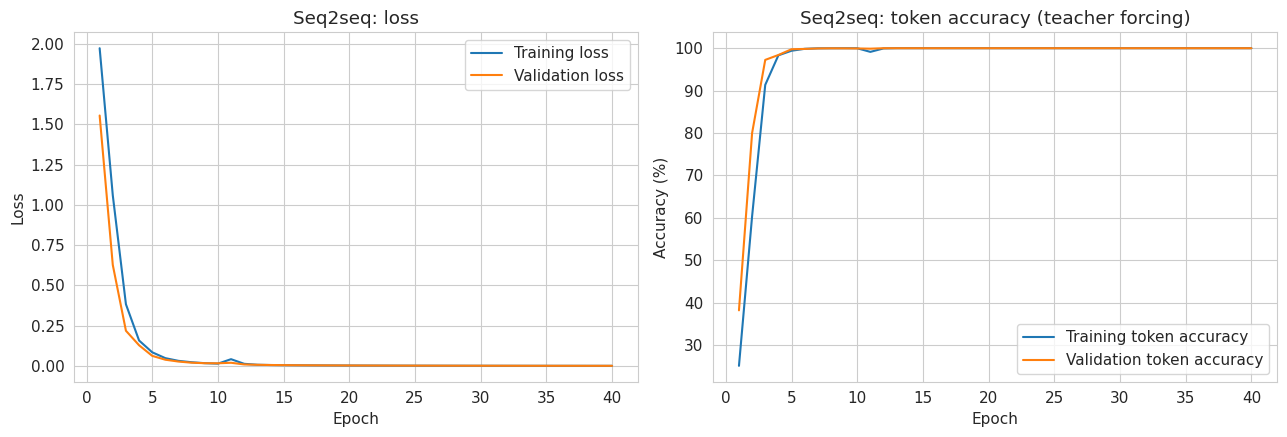


Test-set results (autoregressive decoding)
  Token accuracy    : 100.00%
  Sequence accuracy : 100.00%
  (teacher-forced token accuracy for comparison: 100.00%)
  If errors were independent, expected sequence accuracy = 100.00%  (= token accuracy ^ 6)

Accuracy per output position: {1: np.float64(100.0), 2: np.float64(100.0), 3: np.float64(100.0), 4: np.float64(100.0), 5: np.float64(100.0), 6: np.float64(100.0)}

  Sample     Input sequence    Expected output   Predicted output Correct
      1 [7, 9, 6, 8, 3, 4] [4, 3, 8, 6, 9, 7] [4, 3, 8, 6, 9, 7]     yes
      2 [7, 8, 1, 4, 8, 2] [2, 8, 4, 1, 8, 7] [2, 8, 4, 1, 8, 7]     yes
      3 [4, 5, 1, 9, 4, 8] [8, 4, 9, 1, 5, 4] [8, 4, 9, 1, 5, 4]     yes
      4 [4, 4, 9, 8, 5, 5] [5, 5, 8, 9, 4, 4] [5, 5, 8, 9, 4, 4]     yes
      5 [8, 7, 9, 3, 2, 2] [2, 2, 3, 9, 7, 8] [2, 2, 3, 9, 7, 8]     yes
      6 [5, 3, 8, 8, 2, 9] [9, 2, 8, 8, 3, 5] [9, 2, 8, 8, 3, 5]     yes
      7 [6, 3, 2, 2, 5, 1] [1, 5, 2, 2, 3, 6] [1, 5, 2, 2, 3, 6]     y

In [19]:
# ============================================================
# BLOCK 16: Sequence-to-sequence reversal (encoder-decoder LSTM)
# ============================================================

# ---------- Configuration ----------
S_VOCAB  = 10      # token 0 = <start>, tokens 1-9 = the digits that appear in sequences
S_LEN    = 6       # length of every input and output sequence
S_N      = 10000   # total sequences (70% train / 15% val / 15% test)
S_EMB    = 16
S_UNITS  = 128
S_EPOCHS = 40
S_BATCH  = 64
START    = 0

# ---------- 1. Synthetic data ----------
rng_s = np.random.default_rng(SEED)
Xs = rng_s.integers(1, S_VOCAB, size=(S_N, S_LEN)).astype(np.int32)       # e.g. [3 8 1 5 2 7]
Ys = Xs[:, ::-1].copy()                                                    # reversed: [7 2 5 1 8 3]
# Teacher forcing: the decoder is FED <start> + the true output shifted right by one position
Ds = np.concatenate([np.full((S_N, 1), START, dtype=np.int32), Ys[:, :-1]], axis=1)

n_tr, n_va = int(0.70 * S_N), int(0.15 * S_N)
Xtr, Dtr, Ytr = Xs[:n_tr], Ds[:n_tr], Ys[:n_tr]
Xva, Dva, Yva = Xs[n_tr:n_tr + n_va], Ds[n_tr:n_tr + n_va], Ys[n_tr:n_tr + n_va]
Xte, Dte, Yte = Xs[n_tr + n_va:], Ds[n_tr + n_va:], Ys[n_tr + n_va:]
print(f"Train {Xtr.shape} | Val {Xva.shape} | Test {Xte.shape}")
print("Example  input:", Xtr[0], "| decoder input:", Dtr[0], "| target:", Ytr[0])


# ---------- 2. Encoder-decoder model ----------
def build_seq2seq():
    keras.utils.set_random_seed(SEED)
    # Encoder: reads the input and compresses it into its final states (h, c) = the "context"
    enc_in  = Input(shape=(S_LEN,), name="encoder_input")
    enc_emb = Embedding(S_VOCAB, S_EMB, name="enc_embedding")(enc_in)
    _, h, c = LSTM(S_UNITS, return_state=True, name="encoder_lstm")(enc_emb)
    # Decoder: starts from the encoder's context and predicts one output token per step
    dec_in  = Input(shape=(S_LEN,), name="decoder_input")
    dec_emb = Embedding(S_VOCAB, S_EMB, name="dec_embedding")(dec_in)
    dec_seq = LSTM(S_UNITS, return_sequences=True, name="decoder_lstm")(dec_emb, initial_state=[h, c])
    out     = Dense(S_VOCAB, activation="softmax", name="output")(dec_seq)
    model = Model([enc_in, dec_in], out, name="seq2seq_reverse")
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

seq_model = build_seq2seq()
seq_model.summary()

start = time.time()
seq_hist = seq_model.fit([Xtr, Dtr], Ytr, validation_data=([Xva, Dva], Yva),
                         epochs=S_EPOCHS, batch_size=S_BATCH, verbose=0)
seq_time = time.time() - start
sh = seq_hist.history
print(f"\nTraining time: {seq_time:.1f} s | parameters: {seq_model.count_params():,}")
print(f"Final training loss: {sh['loss'][-1]:.4f} | final validation loss: {sh['val_loss'][-1]:.4f}")

# ---------- 3. Training curves ----------
ep = np.arange(1, S_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, sh["loss"], label="Training loss")
ax[0].plot(ep, sh["val_loss"], label="Validation loss")
ax[0].set(title="Seq2seq: loss", xlabel="Epoch", ylabel="Loss")
ax[1].plot(ep, np.array(sh["accuracy"]) * 100, label="Training token accuracy")
ax[1].plot(ep, np.array(sh["val_accuracy"]) * 100, label="Validation token accuracy")
ax[1].set(title="Seq2seq: token accuracy (teacher forcing)", xlabel="Epoch", ylabel="Accuracy (%)")
for a in ax:
    a.legend()
plt.tight_layout()
plt.show()


# ---------- 4. Real inference: the decoder feeds on its OWN previous predictions ----------
def decode(enc_x):
    """Greedy autoregressive decoding. No true targets are used."""
    n = len(enc_x)
    dec = np.zeros((n, S_LEN), dtype=np.int32)
    dec[:, 0] = START
    pred = np.zeros((n, S_LEN), dtype=np.int32)
    for t in range(S_LEN):
        probs = seq_model.predict([enc_x, dec], verbose=0)     # (n, S_LEN, S_VOCAB)
        pred[:, t] = probs[:, t].argmax(axis=-1)               # token predicted at step t
        if t + 1 < S_LEN:
            dec[:, t + 1] = pred[:, t]                         # feed it back as the next input
    return pred

pred_te = decode(Xte)

# ---------- 5. Required metrics ----------
token_acc = (pred_te == Yte).mean() * 100
seq_acc   = (pred_te == Yte).all(axis=1).mean() * 100
tf_loss, tf_acc = seq_model.evaluate([Xte, Dte], Yte, verbose=0)

print("\nTest-set results (autoregressive decoding)")
print(f"  Token accuracy    : {token_acc:.2f}%")
print(f"  Sequence accuracy : {seq_acc:.2f}%")
print(f"  (teacher-forced token accuracy for comparison: {tf_acc * 100:.2f}%)")
print(f"  If errors were independent, expected sequence accuracy = "
      f"{(token_acc / 100) ** S_LEN * 100:.2f}%  (= token accuracy ^ {S_LEN})")

pos_acc = (pred_te == Yte).mean(axis=0) * 100
print("\nAccuracy per output position:", dict(zip(range(1, S_LEN + 1), pos_acc.round(1))))

# ---------- 6. Example predictions (the lab requires at least five) ----------
ex = pd.DataFrame({
    "Sample": range(1, 11),
    "Input sequence": [list(x) for x in Xte[:10]],
    "Expected output": [list(y) for y in Yte[:10]],
    "Predicted output": [list(p) for p in pred_te[:10]],
    "Correct": ["yes" if (p == y).all() else "NO" for p, y in zip(pred_te[:10], Yte[:10])],
})
print("\n", ex.to_string(index=False))

# ---------- 7. Seq2seq results table ----------
seq_table = pd.DataFrame({"Seq2seq (encoder-decoder LSTM)": {
    "Token accuracy (%)": token_acc, "Sequence accuracy (%)": seq_acc,
    "Final training loss": sh["loss"][-1], "Final validation loss": sh["val_loss"][-1],
    "Parameters": seq_model.count_params(), "Training time (s)": seq_time}})
print("\n", seq_table.round(4).to_string())

In [20]:
# ============================================================
# BLOCK 17: Consolidated results (Section 25) + export
# ============================================================
out_dir = Path.cwd() / "report_tables"
out_dir.mkdir(exist_ok=True)

# ---------- Section 25: consolidated table ----------
rows = []
for k in ["RNN", "LSTM", "GRU"]:
    r = results[k]
    rows.append({"Model": f"{k} (HAR)", "Accuracy (%)": r["accuracy"], "Precision (%)": r["precision"],
                 "Recall (%)": r["recall"], "F1 (%)": r["f1"], "Trainable parameters": r["params"],
                 "Training time (s)": r["train_time_s"]})
for k in ["CNN-LSTM", "CNN-GRU"]:
    r = video_results[k]
    label = f"{k} (UCF101)" + (" - main" if k == SELECTED else " - supplementary")
    rows.append({"Model": label, "Accuracy (%)": r["accuracy"], "Precision (%)": r["precision"],
                 "Recall (%)": r["recall"], "F1 (%)": r["f1"], "Trainable parameters": r["params"],
                 "Training time (s)": r["train_time_s"]})
consolidated = pd.DataFrame(rows).set_index("Model")
print("Consolidated results (test sets; precision/recall/F1 are macro-averaged)\n")
print(consolidated.round(2).to_string())
print(f"\nNote: the video models also use a frozen MobileNetV2 with {base_cnn.count_params():,} "
      f"non-trainable parameters (not counted above).")

# ---------- Separate seq2seq table ----------
print("\nSequence-to-sequence results\n")
print(seq_table.round(4).to_string())

# ---------- Sequence-length table (Section 17) ----------
print("\nTest macro F1 vs. sequence length\n")
print(f1_table.round(2).to_string())

# ---------- Export everything ----------
consolidated.round(4).to_csv(out_dir / "consolidated_results.csv")
results_df.round(4).to_csv(out_dir / "har_test_metrics.csv")
f1_table.round(4).to_csv(out_dir / "f1_vs_sequence_length.csv")
time_table.round(4).to_csv(out_dir / "time_vs_sequence_length.csv")
seq_table.round(4).to_csv(out_dir / "seq2seq_results.csv")
recall_df.round(2).to_csv(out_dir / "har_per_class_recall.csv")
recall_v.round(2).to_csv(out_dir / "video_per_class_recall.csv")
print("\nSaved to:", out_dir)
print(sorted(p.name for p in out_dir.iterdir()))

Consolidated results (test sets; precision/recall/F1 are macro-averaged)

                                  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Trainable parameters  Training time (s)
Model                                                                                                                     
RNN (HAR)                                77.78          78.17       77.78   77.69                  1974              24.50
LSTM (HAR)                               94.17          94.38       94.17   94.17                  6006              19.81
GRU (HAR)                                95.00          95.01       95.00   95.00                  4758              19.76
CNN-LSTM (UCF101) - main                 85.33          86.33       85.33   85.30                168229               6.95
CNN-GRU (UCF101) - supplementary         80.00          80.02       80.00   79.94                126309               6.71

Note: the video models also use a frozen MobileNetV2 with 2,257,